In [1]:
import librosa  # audio loading and feature extraction
import numpy as np  # numerical arrays
import pandas as pd  # dataframes
import matplotlib.pyplot as plt  # plots
import os

In [2]:
DATASET_PATH = r"C:\01_BME\05_Intro to ML\00_MusicGenre\Data\genres_original"
N_MFCC = 20

In [4]:
# mfcc function to extract features from audio segments


def mfcc(segment, sample_rate, n_mfcc=N_MFCC):
    """
    Extract MFCC mean + std features from one audio segment.
    Returns a 1D feature vector.
    """
    mfcc_matrix = librosa.feature.mfcc(y=segment, sr=sample_rate, n_mfcc=n_mfcc)

    mfcc_mean = np.mean(mfcc_matrix, axis=1)
    mfcc_std = np.std(mfcc_matrix, axis=1)

    features = np.concatenate([mfcc_mean, mfcc_std])
    return features

In [5]:
# Chroma and tonnetz features are also useful for music genre classification, but they need so much time


def mfcc_plus(segment, sample_rate, n_mfcc=N_MFCC):
    """
    Extract MFCC, chroma, and tonnetz features from one audio segment.
    Returns a 1D feature vector.
    """
    mfcc_matrix = librosa.feature.mfcc(y=segment, sr=sample_rate, n_mfcc=n_mfcc)

    chroma_matrix = librosa.feature.chroma_stft(y=segment, sr=sample_rate)

    tonnetz_matrix = librosa.feature.tonnetz(y=segment, sr=sample_rate)

    mfcc_mean = np.mean(mfcc_matrix, axis=1)
    mfcc_std = np.std(mfcc_matrix, axis=1)

    chroma_mean = np.mean(chroma_matrix, axis=1)
    chroma_std = np.std(chroma_matrix, axis=1)

    tonnetz_mean = np.mean(tonnetz_matrix, axis=1)
    tonnetz_std = np.std(tonnetz_matrix, axis=1)

    features = np.concatenate(
        [mfcc_mean, mfcc_std, chroma_mean, chroma_std, tonnetz_mean, tonnetz_std]
    )
    return features

In [6]:
def add_gaussian_noise(audio, noise_factor=0.005):
    noise = np.random.randn(len(audio))
    noisy_audio = audio + noise_factor * noise
    noisy_audio = np.clip(noisy_audio, -1.0, 1.0)
    return noisy_audio

In [7]:
def load_data_plus(
    dataset_path=DATASET_PATH,
    n_mfcc=N_MFCC,
    segment_duration=None,
    overlap_duration=0.0,
    augment=False,
    noise_factor=0.005,
    augment_copies=1,
):
    """
    Load the dataset and extract a richer feature set with MFCC, chroma and tonnetz.

    It goes through each genre folder, and for each audio file,
    it extracts features using mfcc_other and stores them together with
    the corresponding genre labels.

    Parameters
    ----------
    segment_duration : float or None
        If None, each file is processed as a whole.
        If a number (e.g. 10.0), each audio file is split into
        fixed-length segments.

    overlap_duration : float
        Overlap between consecutive segments in seconds.
        Example:
        segment_duration=10.0, overlap_duration=2.0
        -> segments like 0-10, 8-18, 16-26, ...
        Default is 0.0 (no overlap).

    augment : bool
        If True, Gaussian-noise augmented copies are added.

    noise_factor : float
        Strength of the Gaussian noise.

    augment_copies : int
        Number of noisy copies generated per original sample.
    """

    features = []
    labels = []

    for genre in os.listdir(dataset_path):
        genre_path = os.path.join(dataset_path, genre)

        if not os.path.isdir(genre_path):
            continue

        for file in os.listdir(genre_path):
            file_path = os.path.join(genre_path, file)

            if not file_path.endswith(".wav"):
                continue

            try:
                audio, sample_rate = librosa.load(file_path, sr=None)
            except Exception as e:
                print(f"Skipping {file_path} due to load error: {e}")
                continue

            if segment_duration is None:
                features_single = mfcc_plus(segment=audio, sample_rate=sample_rate, n_mfcc=n_mfcc)

                features.append(features_single)
                labels.append(genre)

                if augment:
                    for _ in range(augment_copies):
                        noisy_audio = add_gaussian_noise(audio, noise_factor=noise_factor)

                        noisy_features = mfcc_plus(
                            segment=noisy_audio, sample_rate=sample_rate, n_mfcc=n_mfcc
                        )

                        features.append(noisy_features)
                        labels.append(genre)

            else:
                samples_per_segment = int(sample_rate * segment_duration)
                samples_overlap = int(sample_rate * overlap_duration)
                step = samples_per_segment - samples_overlap

                if step <= 0:
                    raise ValueError("overlap_duration must be smaller than segment_duration")

                if len(audio) < samples_per_segment:
                    continue

                for start in range(0, len(audio) - samples_per_segment + 1, step):
                    end = start + samples_per_segment
                    segment = audio[start:end]

                    features_single = mfcc_plus(
                        segment=segment, sample_rate=sample_rate, n_mfcc=n_mfcc
                    )

                    features.append(features_single)
                    labels.append(genre)

                    if augment:
                        for _ in range(augment_copies):
                            noisy_segment = add_gaussian_noise(segment, noise_factor=noise_factor)

                            noisy_features = mfcc_plus(
                                segment=noisy_segment, sample_rate=sample_rate, n_mfcc=n_mfcc
                            )

                            features.append(noisy_features)
                            labels.append(genre)

    return np.array(features), np.array(labels)

In [8]:
def load_data(
    dataset_path=DATASET_PATH,
    n_mfcc=N_MFCC,
    segment_duration=None,
    overlap_duration=0.0,
    augment=False,
    noise_factor=0.005,
    augment_copies=1,
):
    """
    Load the dataset and extract features and labels.

    It goes through each genre folder, and for each audio file,
    it extracts MFCC-based features and stores them together with
    the corresponding genre labels.

    Parameters
    ----------
    segment_duration : float or None
        If None, each file is processed as a whole.
        If a number (e.g. 10.0), each audio file is split into
        fixed-length segments.

    overlap_duration : float
        Overlap between consecutive segments in seconds.
        Example:
        segment_duration=10.0, overlap_duration=2.0
        -> segments like 0-10, 8-18, 16-26, ...
        Default is 0.0 (no overlap).

    augment : bool
        If True, Gaussian-noise augmented copies are added.

    noise_factor : float
        Strength of the Gaussian noise.

    augment_copies : int
        Number of noisy copies generated per original sample.
    """

    features = []
    labels = []

    for genre in os.listdir(dataset_path):
        genre_path = os.path.join(dataset_path, genre)

        if not os.path.isdir(genre_path):
            continue

        for file in os.listdir(genre_path):
            file_path = os.path.join(genre_path, file)

            if not file_path.endswith(".wav"):
                continue

            try:
                audio, sample_rate = librosa.load(file_path, sr=None)
            except Exception as e:
                print(f"Skipping {file_path} due to load error: {e}")
                continue

            if segment_duration is None:
                mfcc_features = mfcc(segment=audio, sample_rate=sample_rate, n_mfcc=n_mfcc)

                features.append(mfcc_features)
                labels.append(genre)

                if augment:
                    for _ in range(augment_copies):
                        noisy_audio = add_gaussian_noise(audio, noise_factor=noise_factor)

                        noisy_features = mfcc(
                            segment=noisy_audio, sample_rate=sample_rate, n_mfcc=n_mfcc
                        )

                        features.append(noisy_features)
                        labels.append(genre)

            else:
                samples_per_segment = int(sample_rate * segment_duration)
                samples_overlap = int(sample_rate * overlap_duration)
                step = samples_per_segment - samples_overlap

                if step <= 0:
                    raise ValueError("overlap_duration must be smaller than segment_duration")

                if len(audio) < samples_per_segment:
                    continue

                for start in range(0, len(audio) - samples_per_segment + 1, step):
                    end = start + samples_per_segment
                    segment = audio[start:end]

                    mfcc_features = mfcc(segment=segment, sample_rate=sample_rate, n_mfcc=n_mfcc)

                    features.append(mfcc_features)
                    labels.append(genre)

                    if augment:
                        for _ in range(augment_copies):
                            noisy_segment = add_gaussian_noise(segment, noise_factor=noise_factor)

                            noisy_features = mfcc(
                                segment=noisy_segment, sample_rate=sample_rate, n_mfcc=n_mfcc
                            )

                            features.append(noisy_features)
                            labels.append(genre)

    return np.array(features), np.array(labels)

In [ ]:
# Load the dataset and extract features 

# this not the load_data_plus function, because that is more complex and takes much longer to run


X, y = load_data(segment_duration=6, overlap_duration=1.5, augment=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Genres found:", np.unique(y))

C:\Users\User\AppData\Local\Temp\ipykernel_7536\1677506452.py:57: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(file_path, sr=None)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipping C:\01_BME\05_Intro to ML\00_MusicGenre\Data\genres_original\jazz\jazz.00054.wav due to load error: 
X shape: (11988, 40)
y shape: (11988,)
Genres found: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


In [36]:
# DO NOT USE AT FIRST, AS IT TAKES SO MUCH TIME 
# Load the dataset with the new feature extraction method

#X, y = load_data_plus(
#    segment_duration=6, overlap_duration=2.0, augment=True, noise_factor=0.01, augment_copies=1
#)

#print("X shape:", X.shape)
#print("y shape:", y.shape)
#print("Genres found:", np.unique(y))

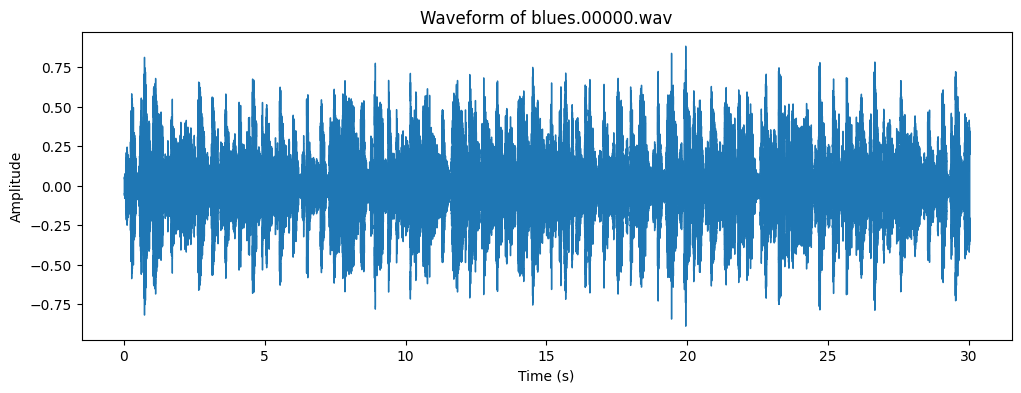

In [11]:
# Plotting the first audio file's waveform and MFCC heatmap for visualization
# cell 9
sample_file = os.path.join(DATASET_PATH, "blues", "blues.00000.wav")

audio, sample_rate = librosa.load(sample_file)

plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio, sr=sample_rate)
plt.title("Waveform of blues.00000.wav")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

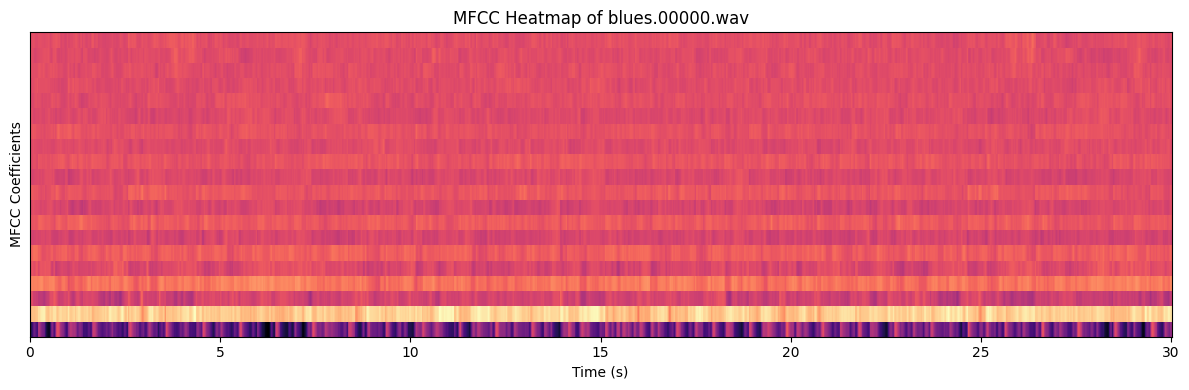

In [12]:
# Extract MFCC features for the sample file
# cell 10
sample_file = os.path.join(DATASET_PATH, "blues", "blues.00000.wav")
audio, sample_rate = librosa.load(sample_file)

mfcc_matrix = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=N_MFCC)

plt.figure(figsize=(12, 4))
librosa.display.specshow(mfcc_matrix, x_axis="time", sr=sample_rate, cmap="magma")
plt.title("MFCC Heatmap of blues.00000.wav")
plt.xlabel("Time (s)")
plt.ylabel("MFCC Coefficients")
plt.tight_layout()
plt.show()

In [13]:
# Cell 11 — Encode labels, split data, and scale correctly

# correct ML workflow:
# X, y saved → label encoding → train/test split → scaling → model training


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Encode string genre labels into numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# First split into train and test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale only after the split
# Fit scaler only on training data, then transform both train and test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Classes:", label_encoder.classes_)

Training data shape: (9590, 40)
Test data shape: (2398, 40)
Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


In [32]:
# Cell 12: Train K-NN
knn = KNeighborsClassifier(n_neighbors=3, metric="manhattan", weights="distance")
# use n_neighbors=5, because as it grows, it reduces the variance of the model, but it can also increase bias, so it can be tuned further
# instead of 'uniform' values, to give more weight to closer neighbors
# use manhattan distance instead of euclidean, as it can perform better in high-dimensional spaces
knn.fit(X_train, y_train)

# Evaluate
y_pred_knn = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy: {acc * 100:.2f}%")
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))

Accuracy: 93.37%
              precision    recall  f1-score   support

       blues       0.97      0.93      0.95       240
   classical       0.96      0.96      0.96       240
     country       0.94      0.85      0.89       240
       disco       0.88      0.95      0.91       240
      hiphop       0.95      0.95      0.95       240
        jazz       0.94      0.94      0.94       238
       metal       0.95      0.95      0.95       240
         pop       0.96      0.98      0.97       240
      reggae       0.87      0.95      0.91       240
        rock       0.94      0.88      0.91       240

    accuracy                           0.93      2398
   macro avg       0.93      0.93      0.93      2398
weighted avg       0.93      0.93      0.93      2398



In [15]:
# Cell 13 — Train Random Forest baseline model

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf * 100:.2f}%")

print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Random Forest Accuracy: 88.28%
              precision    recall  f1-score   support

       blues       0.88      0.86      0.87       240
   classical       0.93      0.98      0.96       240
     country       0.87      0.78      0.82       240
       disco       0.87      0.88      0.87       240
      hiphop       0.90      0.85      0.87       240
        jazz       0.86      0.92      0.89       238
       metal       0.89      0.94      0.91       240
         pop       0.97      0.95      0.96       240
      reggae       0.85      0.90      0.87       240
        rock       0.82      0.76      0.79       240

    accuracy                           0.88      2398
   macro avg       0.88      0.88      0.88      2398
weighted avg       0.88      0.88      0.88      2398



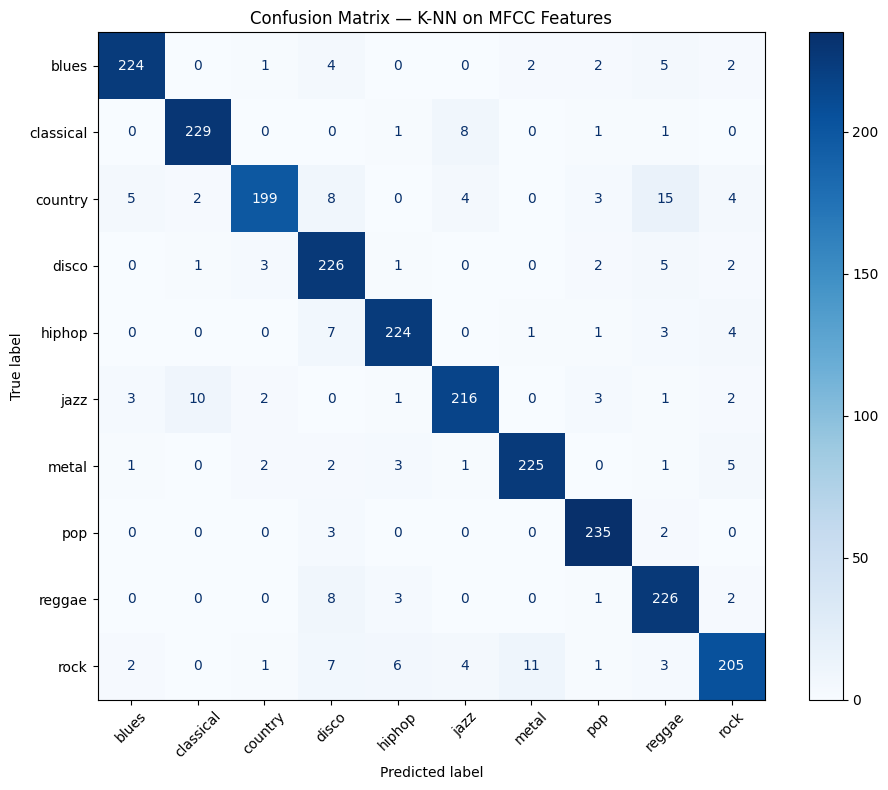

In [16]:
# Cell 14
# Confusion matrix for K-NN

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    display_labels=label_encoder.classes_,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
)
plt.title("Confusion Matrix — K-NN on MFCC Features")
plt.tight_layout()
plt.show()

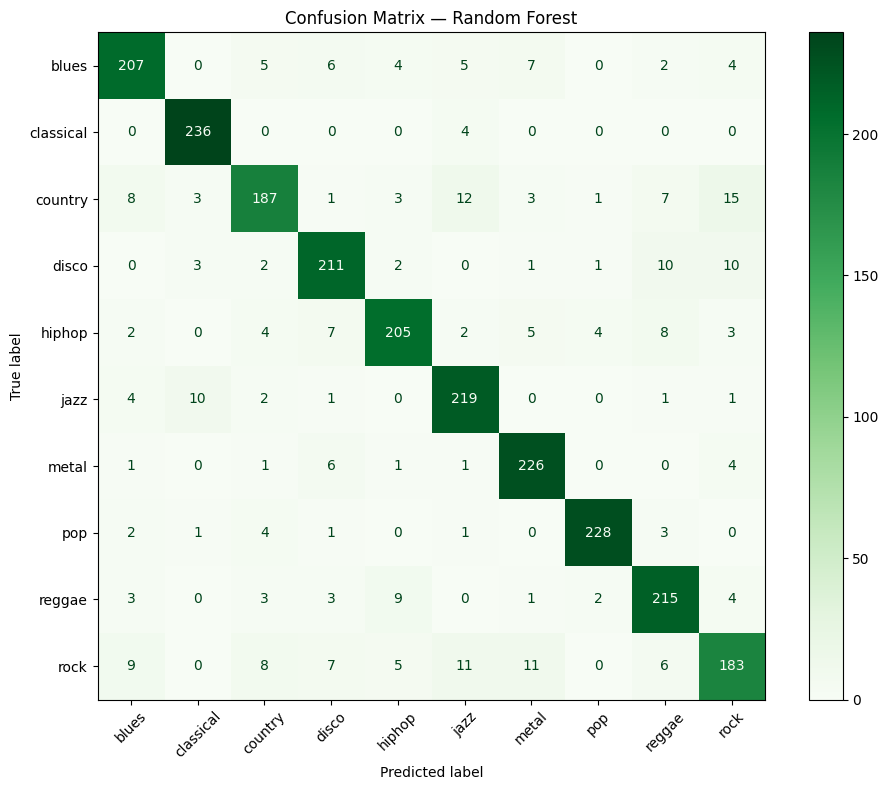

In [26]:
# Cell 15 — Confusion matrix for Random Forest

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=label_encoder.classes_,
    cmap="Greens",
    xticks_rotation=45,
    ax=ax
)

plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

In [18]:
# Cell 16 — Predict genre for a new audio file
def predict_genre(
    file_path,
    model=knn,
    label_encoder=label_encoder,
    scaler=scaler,
    n_mfcc=N_MFCC,
    segment_duration=6.0,
):
    """
    Predict genre by averaging predictions over multiple segments of a WAV file.
    """

    try:
        audio, sample_rate = librosa.load(file_path, sr=None)
    except Exception as e:
        print(f"Could not load file: {e}")
        return None

    samples_per_segment = int(sample_rate * segment_duration)
    n_segments = len(audio) // samples_per_segment

    if n_segments == 0:
        print("Audio file is shorter than one segment.")
        return None

    segments = [
        audio[i * samples_per_segment : (i + 1) * samples_per_segment] for i in range(n_segments)
    ]

    predictions = []

    for segment in segments:
        features = mfcc(segment=segment, sample_rate=sample_rate, n_mfcc=n_mfcc)

        features_scaled = scaler.transform(features.reshape(1, -1))
        pred = model.predict(features_scaled)[0]
        predictions.append(pred)

    final_prediction = max(set(predictions), key=predictions.count)
    genre = label_encoder.inverse_transform([final_prediction])[0]

    print(f"Segments analyzed: {n_segments}")

    votes = {
        label_encoder.inverse_transform([p])[0]: predictions.count(p) for p in set(predictions)
    }

    print(f"Votes per genre: {votes}")
    print(f"Predicted genre: {genre}")

    return genre

In [ ]:
# Cell 17 — Predict genre for a new audio file

# feature vector is MFCC + chroma + tonnetz
def predict_genre_plus(
    file_path,
    model=knn,
    label_encoder=label_encoder,
    scaler=scaler,
    n_mfcc=N_MFCC,
    segment_duration=10.0,
):
    """
    Predict genre by averaging predictions over multiple segments of a WAV file.
    """

    try:
        audio, sample_rate = librosa.load(file_path, sr=None)
    except Exception as e:
        print(f"Could not load file: {e}")
        return None

    samples_per_segment = int(sample_rate * segment_duration)
    n_segments = len(audio) // samples_per_segment

    if n_segments == 0:
        print("Audio file is shorter than one segment.")
        return None

    segments = [
        audio[i * samples_per_segment : (i + 1) * samples_per_segment] for i in range(n_segments)
    ]

    predictions = []

    for segment in segments:
        features = mfcc_plus(segment=segment, sample_rate=sample_rate, n_mfcc=n_mfcc)

        features_scaled = scaler.transform(features.reshape(1, -1))
        pred = model.predict(features_scaled)[0]
        predictions.append(pred)

    final_prediction = max(set(predictions), key=predictions.count)
    genre = label_encoder.inverse_transform([final_prediction])[0]

    print(f"Segments analyzed: {n_segments}")

    votes = {
        label_encoder.inverse_transform([p])[0]: predictions.count(p) for p in set(predictions)
    }

    print(f"Votes per genre: {votes}")
    print(f"Predicted genre: {genre}")

    return genre

## Hyperparameter optimalisation

In [ ]:
# Cell 18 — KNN hyperparameter optimization with GridSearchCV

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Cross-validation setup
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Hyperparameter search space for KNN
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

# Grid search on training data only
knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

knn_grid.fit(X_train, y_train)

print("Best KNN parameters:")
print(knn_grid.best_params_)

print(f"\nBest cross-validation accuracy: {knn_grid.best_score_ * 100:.2f}%")

# Best optimized KNN model
best_knn = knn_grid.best_estimator_

# Test set evaluation
y_pred_best_knn = best_knn.predict(X_test)

acc_best_knn = accuracy_score(y_test, y_pred_best_knn)

print(f"\nOptimized KNN test accuracy: {acc_best_knn * 100:.2f}%")

print("\nOptimized KNN classification report:")
print(classification_report(
    y_test,
    y_pred_best_knn,
    target_names=label_encoder.classes_
))

Fitting 5 folds for each of 42 candidates, totalling 210 fits
Best KNN parameters:
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

Best cross-validation accuracy: 92.12%

Optimized KNN test accuracy: 93.37%

Optimized KNN classification report:
              precision    recall  f1-score   support

       blues       0.97      0.93      0.95       240
   classical       0.96      0.96      0.96       240
     country       0.94      0.85      0.89       240
       disco       0.88      0.95      0.91       240
      hiphop       0.95      0.95      0.95       240
        jazz       0.94      0.94      0.94       238
       metal       0.95      0.95      0.95       240
         pop       0.96      0.98      0.97       240
      reggae       0.87      0.95      0.91       240
        rock       0.94      0.88      0.91       240

    accuracy                           0.93      2398
   macro avg       0.93      0.93      0.93      2398
weighted avg       0.93      0.93

### Random Forest Optimalisation

In [ ]:
# Cell 19 — Random Forest hyperparameter optimization with RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=25,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_random.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_random.best_params_)

print(f"\nBest cross-validation accuracy: {rf_random.best_score_ * 100:.2f}%")

best_rf = rf_random.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

acc_best_rf = accuracy_score(y_test, y_pred_best_rf)

print(f"\nOptimized Random Forest test accuracy: {acc_best_rf * 100:.2f}%")

print(classification_report(
    y_test,
    y_pred_best_rf,
    target_names=label_encoder.classes_
))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Random Forest parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best cross-validation accuracy: 85.67%

Optimized Random Forest test accuracy: 88.41%
              precision    recall  f1-score   support

       blues       0.91      0.87      0.89       240
   classical       0.94      0.97      0.96       240
     country       0.87      0.80      0.83       240
       disco       0.86      0.86      0.86       240
      hiphop       0.90      0.87      0.88       240
        jazz       0.85      0.93      0.89       238
       metal       0.86      0.93      0.89       240
         pop       0.97      0.96      0.96       240
      reggae       0.83      0.89      0.86       240
        rock       0.84      0.77      0.80       240

    accuracy                           0.88      2398
   macro avg       0.88      0.88      0.88      2398
weig

## Save and Load Models

In [ ]:
# Cell 20 — Save final optimized KNN model and preprocessing objects

import joblib

joblib.dump(best_knn, "best_knn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Final model saved successfully.")
print("Saved files:")
print("- best_knn_model.pkl")
print("- scaler.pkl")
print("- label_encoder.pkl")

In [ ]:
# Cell 18 — Predict genre of a new audio file using final optimized KNN model

import joblib

# Load saved model and preprocessing objects
best_knn = joblib.load("best_knn_model.pkl")
scaler = joblib.load("scaler.pkl")
label_encoder = joblib.load("label_encoder.pkl")

# Real Song Predictions

In [ ]:
# Cell 20 test

predict_genre(
    r"C:\\Users\\bruno\\Desktop\\BME\\4th_Sem\\5_machine_learning\\FINAL\\genres\\Pink Floyd - Another Brick in the Wall Official Music Video (Lyrics In Description).wav", model=best_knn
)

Predicted genre: reggae

Segment votes:
classical: 2
country: 5
disco: 6
hiphop: 5
jazz: 9
pop: 8
reggae: 17
rock: 8


np.str_('reggae')

In [ ]:
predict_genre(
    r"C:\\Users\\bruno\\Desktop\\BME\\4th_Sem\\5_machine_learning\\FINAL\\genres\\Pink Floyd - Another Brick in the Wall Official Music Video (Lyrics In Description).wav", model=rf
)

Predicted genre: reggae

Segment votes:
blues: 1
classical: 11
country: 12
jazz: 9
pop: 8
reggae: 18
rock: 1


np.str_('reggae')

In [29]:
predict_genre(file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\Another Brick in the Wall.wav")

Segments analyzed: 39
Votes per genre: {np.str_('reggae'): 33, np.str_('hiphop'): 6}
Predicted genre: reggae


np.str_('reggae')

In [28]:
predict_genre(
    file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\Another Brick in the Wall.wav", model=rf
)

Segments analyzed: 39
Votes per genre: {np.str_('reggae'): 35, np.str_('classical'): 1, np.str_('country'): 3}
Predicted genre: reggae


np.str_('reggae')

In [27]:
predict_genre(
    file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\AC DC Highway to hell.wav", model=knn
)

Segments analyzed: 34
Votes per genre: {np.str_('blues'): 11, np.str_('classical'): 1, np.str_('country'): 2, np.str_('hiphop'): 7, np.str_('jazz'): 1, np.str_('metal'): 6, np.str_('reggae'): 3, np.str_('rock'): 3}
Predicted genre: blues


np.str_('blues')

In [34]:
# prediction with the kNN model
predict_genre(
    file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\Anastacia - I'm outta love.wav", model=knn
)

Segments analyzed: 39
Votes per genre: {np.str_('blues'): 16, np.str_('country'): 2, np.str_('disco'): 2, np.str_('hiphop'): 8, np.str_('metal'): 2, np.str_('pop'): 1, np.str_('reggae'): 8}
Predicted genre: blues


np.str_('blues')

## Results after hyperparameter optimization

After extracting MFCC-based features from the music tracks, we trained two classifiers: K-Nearest Neighbors and Random Forest. 

For the optimization of KNN, we used GridSearchCV with stratified 5-fold cross-validation. The tuned hyperparameters were the number of neighbors, the distance metric, and the weighting method. The optimized model was selected based only on the training data, while the test data was kept separate for final evaluation.

The optimized KNN model was then evaluated on the test set and compared with the baseline KNN and Random Forest models. The confusion matrix was used to inspect which genres were classified correctly and which genres were commonly confused.

# TSNE visualisation

Number of points used for t-SNE: 2000
Number of features before dimensionality reduction: 40
Number of features after PCA: 30


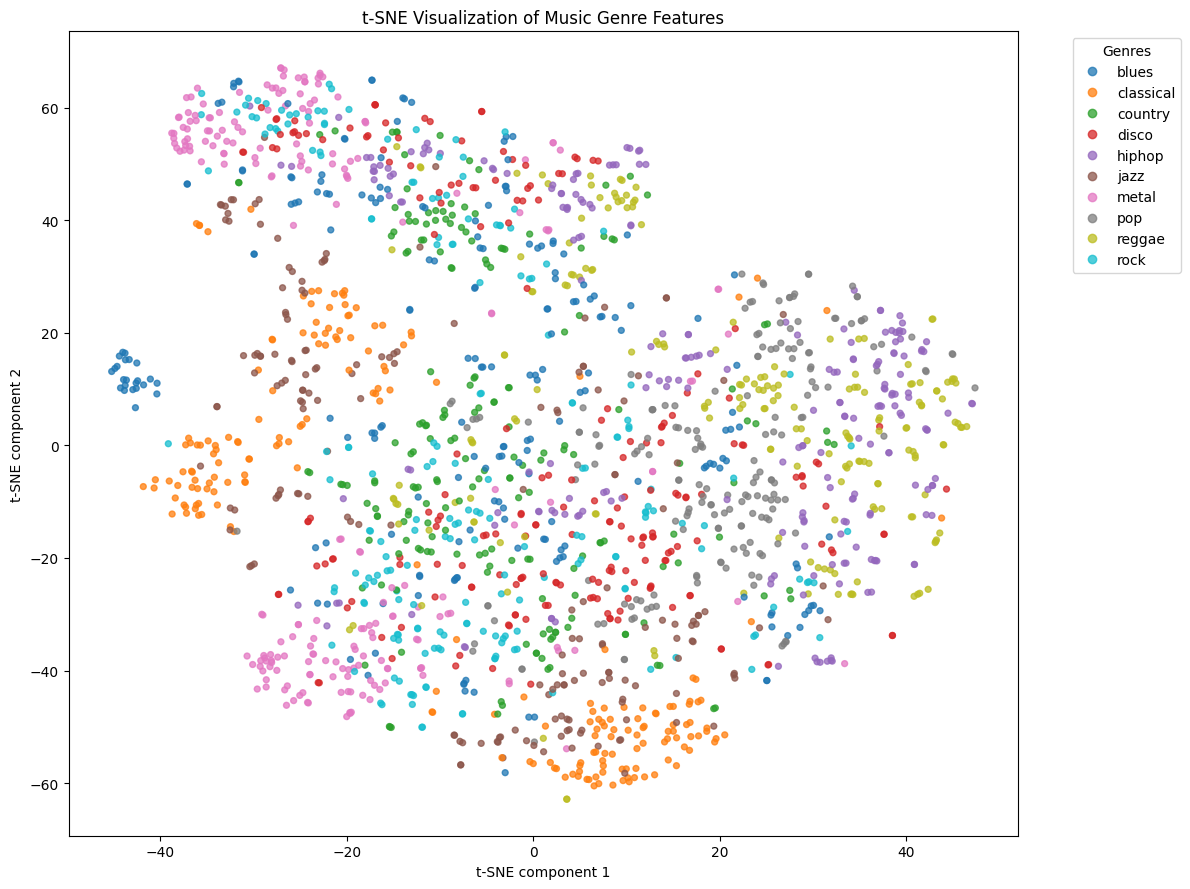

In [39]:
# tsne

# Cell 23 — t-SNE visualization of extracted music features

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Scale the full feature dataset using the scaler fitted on the training data
# This keeps the same preprocessing logic as the trained models
X_all_scaled = scaler.transform(X)

# Use encoded labels for coloring
y_all_encoded = label_encoder.transform(y)

# t-SNE can be slow, so we optionally sample part of the dataset
# If your dataset is small enough, this will simply use all points
max_points = 2000

if X_all_scaled.shape[0] > max_points:
    np.random.seed(42)
    selected_indices = np.random.choice(
        X_all_scaled.shape[0],
        size=max_points,
        replace=False
    )

    X_tsne_input = X_all_scaled[selected_indices]
    y_tsne_labels = y_all_encoded[selected_indices]
else:
    X_tsne_input = X_all_scaled
    y_tsne_labels = y_all_encoded

print("Number of points used for t-SNE:", X_tsne_input.shape[0])
print("Number of features before dimensionality reduction:", X_tsne_input.shape[1])

# Optional PCA preprocessing:
# This speeds up t-SNE and removes some noise before the 2D projection
pca = PCA(n_components=min(30, X_tsne_input.shape[1]), random_state=42)
X_pca = pca.fit_transform(X_tsne_input)

print("Number of features after PCA:", X_pca.shape[1])

# t-SNE projection to 2D
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca)

# Plot t-SNE result
plt.figure(figsize=(12, 9))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_tsne_labels,
    cmap="tab10",
    s=18,
    alpha=0.75
)

# Create legend with genre names
handles, _ = scatter.legend_elements()
plt.legend(
    handles,
    label_encoder.classes_,
    title="Genres",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("t-SNE Visualization of Music Genre Features")
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.tight_layout()
plt.show()

## t-SNE visualization

t-SNE was used to visualize the extracted audio features in two dimensions. The original feature vectors are high-dimensional, so they cannot be plotted directly. t-SNE reduces these feature vectors to two components while trying to preserve local similarities between samples.

In this project, each point represents one audio segment. The color of the point represents the true music genre. If points with the same color appear close together, it means that the extracted MFCC-based features contain useful information for separating that genre. If different colors overlap, it means those genres have similar audio characteristics and are harder for the classifier to distinguish.

This visualization is not used for training the model. It is only used to understand how well the extracted features separate the music genres.

The t-SNE plot shows that some genres form relatively clear clusters, which explains why the KNN classifier performs well. However, some genres overlap in the feature space, which also explains the confusion seen in the confusion matrix.